In [2]:
import pandas as pd

In [3]:
drivers = pd.read_csv("../data/drivers.csv")
races = pd.read_csv("../data/races.csv")
results = pd.read_csv("../data/results.csv")
constructors = pd.read_csv("../data/constructors.csv")
circuits = pd.read_csv("../data/circuits.csv")

In [4]:
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [5]:
print("Drivers:", drivers.shape)
print("Races:", races.shape)
print("Results:", results.shape)

Drivers: (861, 9)
Races: (1125, 18)
Results: (26759, 18)


In [6]:
results.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='object')

In [7]:
drivers.head()
races.head()
results.head()



,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [8]:
df = pd.merge(results, races, on="raceId", suffixes=("_result", "_race"))

In [9]:
df = pd.merge(df, drivers, on="driverId")

In [10]:
df = pd.merge(df, constructors, on="constructorId")

In [11]:
df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url
0,1,18,1,1,22,1,1,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,18,4,4,5,11,4,4,4,5.0,...,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,18,5,1,23,3,5,5,5,4.0,...,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren


In [12]:
df.shape

(26759, 47)

In [13]:
df["driver_name"] = df["forename"] + " " + df["surname"]

In [14]:
df[["driver_name","year","position"]].head()

,driver_name,year,position
0,Lewis Hamilton,2008,1
1,Nick Heidfeld,2008,2
2,Nico Rosberg,2008,3
3,Fernando Alonso,2008,4
4,Heikki Kovalainen,2008,5


In [15]:
df.to_csv("../data/f1_merged.csv", index=False)

In [17]:


import pandas as pd

df = pd.read_csv("../data/f1_merged.csv")

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_8860\2779980502.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/f1_merged.csv")


,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url,driver_name
0,1,18,1,1,22,1,1,1,1,10.0,...,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Lewis Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,Nick Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,Nico Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,Fernando Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Heikki Kovalainen


In [22]:
df["position"] = pd.to_numeric(df["position"], errors="coerce")
df["win"] = df["position"] == 1

In [23]:
df[["driver_name","position","win"]].head()

,driver_name,position,win
0,Lewis Hamilton,1.0,True
1,Nick Heidfeld,2.0,False
2,Nico Rosberg,3.0,False
3,Fernando Alonso,4.0,False
4,Heikki Kovalainen,5.0,False


In [24]:
top_drivers = df.groupby("driver_name")["win"].sum().sort_values(ascending=False).head(10)

top_drivers

driver_name
Lewis Hamilton        105
Michael Schumacher     91
Max Verstappen         63
Sebastian Vettel       53
Alain Prost            51
Ayrton Senna           41
Fernando Alonso        32
Nigel Mansell          31
Jackie Stewart         27
Niki Lauda             25
Name: win, dtype: int64

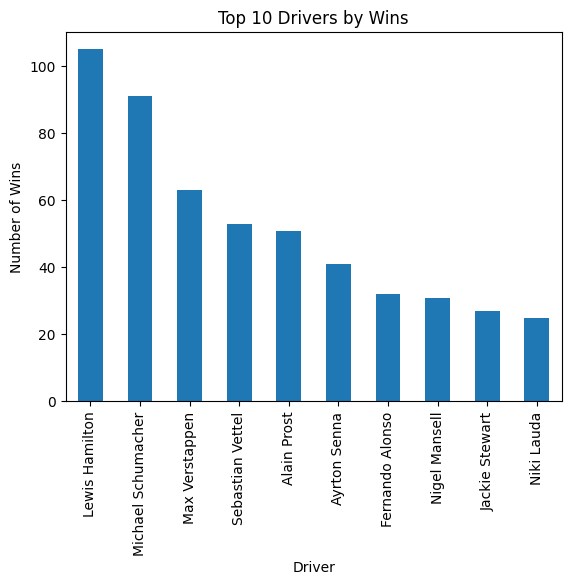

In [25]:
import matplotlib.pyplot as plt

top_drivers.plot(kind="bar")

plt.title("Top 10 Drivers by Wins")
plt.xlabel("Driver")
plt.ylabel("Number of Wins")

plt.show()

In [28]:
df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number_x', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps',
       'time_result', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name_x',
       'date', 'time_race', 'url_x', 'fp1_date', 'fp1_time', 'fp2_date',
       'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time',
       'sprint_date', 'sprint_time', 'driverRef', 'number_y', 'code',
       'forename', 'surname', 'dob', 'nationality_x', 'url_y',
       'constructorRef', 'name_y', 'nationality_y', 'url', 'driver_name',
       'win'],
      dtype='object')

In [29]:
top_teams = df.groupby("name_y")["win"].sum().sort_values(ascending=False).head(10)

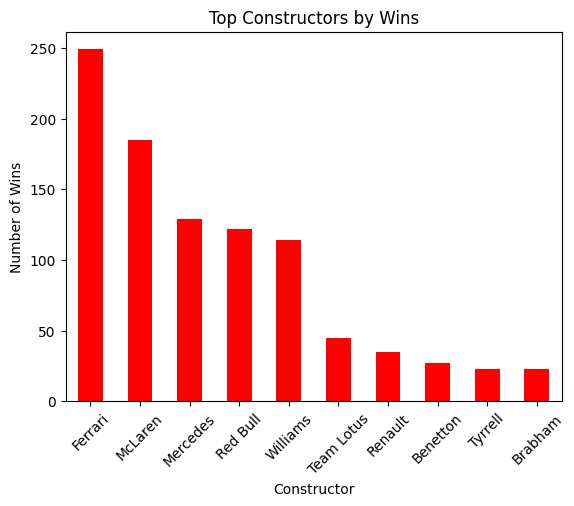

In [30]:
import matplotlib.pyplot as plt

top_teams.plot(kind="bar", color="red")

plt.title("Top Constructors by Wins")
plt.xlabel("Constructor")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)

plt.show()

In [31]:
df[["year","name_x"]].head()

,year,name_x
0,2008,Australian Grand Prix
1,2008,Australian Grand Prix
2,2008,Australian Grand Prix
3,2008,Australian Grand Prix
4,2008,Australian Grand Prix


In [32]:
top_circuits = df.groupby("name_x").size().sort_values(ascending=False).head(10)

top_circuits

name_x
British Grand Prix          1873
Italian Grand Prix          1864
Monaco Grand Prix           1664
German Grand Prix           1599
Belgian Grand Prix          1597
French Grand Prix           1484
Canadian Grand Prix         1291
Spanish Grand Prix          1276
Brazilian Grand Prix        1143
United States Grand Prix    1049
dtype: int64

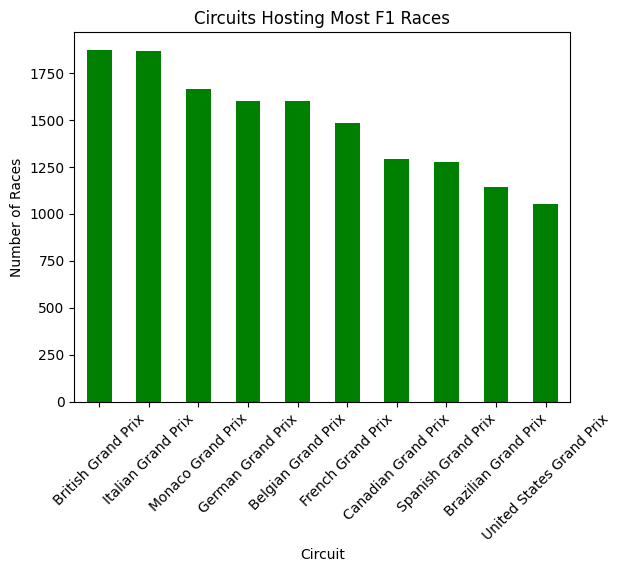

In [33]:
import matplotlib.pyplot as plt

top_circuits.plot(kind="bar", color="green")

plt.title("Circuits Hosting Most F1 Races")
plt.xlabel("Circuit")
plt.ylabel("Number of Races")
plt.xticks(rotation=45)

plt.show()